In [17]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import numpy as np

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Configuration
LOG_DIR = "../models/rl_filter"  # Adjust if your logs are elsewhere

In [18]:
def load_logs(log_dir):
    all_records = []
    # Look for analysis_logs_cycle_*.jsonl
    log_files = sorted(glob.glob(os.path.join(log_dir, "analysis_logs_cycle_*.jsonl")))
    
    if not log_files:
        print(f"No log files found in {log_dir}")
        return pd.DataFrame()
        
    print(f"Found {len(log_files)} log files.")
    
    for file_path in log_files:
        try:
            cycle_num = int(file_path.split('_cycle_')[-1].split('.')[0])
        except ValueError:
            cycle_num = 0
            
        with open(file_path, 'r') as f:
            for line in f:
                try:
                    episode = json.loads(line)
                except json.JSONDecodeError:
                    continue
                
                # Extract episode-level metrics
                ep_id = episode.get('episode_id')
                task_group_id = episode.get('task_group_id')  # Task group for GRPO (0, 1, 2, ...)
                sample_id = episode.get('sample_id')  # Sample within task group
                task_id = episode.get('task_id')  # Actual task ID from config
                final_reward = episode.get('final_reward')
                success = episode.get('success')
                
                # Extract recall events
                for recall in episode.get('recall_events', []):
                    obs_text = recall.get('observation_text', '')
                    goal_text = recall.get('goal_text', '')
                    
                    for cand in recall.get('candidates', []):
                        record = {
                            'cycle': cycle_num,
                            'episode_id': ep_id,
                            'task_group_id': task_group_id,
                            'sample_id': sample_id,
                            'task_id': task_id,
                            'final_reward': final_reward,
                            'success': success,
                            'observation_text': obs_text,
                            'goal_text': goal_text,
                            'memory_id': cand.get('memory_id'),
                            'similarity_score': cand.get('similarity_score'),
                            'gate_score': cand.get('gate_score'),
                            'gate_action': cand.get('gate_action'), # 1=Keep, 0=Discard
                            'selected': cand.get('selected'),
                            'memory_content': cand.get('memory_content')
                        }
                        all_records.append(record)
                        
    return pd.DataFrame(all_records)

df = load_logs(LOG_DIR)
if not df.empty:
    print(f"Loaded {len(df)} memory candidate evaluations.")
    display(df.head())
else:
    print("DataFrame is empty. Please run training to generate logs.")

Found 1 log files.
Loaded 144 memory candidate evaluations.


,cycle,episode_id,task_group_id,sample_id,task_id,final_reward,success,observation_text,goal_text,memory_id,similarity_score,gate_score,gate_action,selected,memory_content
0,1,4483590400,0,0,168,1.5,True,The provided text appears to be a web observat...,Tell me the full names of the repositories whe...,be137ffc-d974-4033-8354-960a45ec6900,0.927860,None,None,True,{'obs_summary': '**Page Overview** - **URL**...
1,1,4483590400,0,0,168,1.5,True,The provided text appears to be a web observat...,Tell me the full names of the repositories whe...,567a6047-59a8-4777-9574-ba40bc35f64b,0.920149,None,None,True,{'obs_summary': '**Page:** GitLab – Dashboard ...
2,1,4483590400,0,0,168,1.5,True,The provided text appears to be a web observat...,Tell me the full names of the repositories whe...,1fa01ac1-fe76-454e-9c51-e2fadea1fbf8,0.907921,None,None,True,{'obs_summary': 'The provided text appears to ...
3,1,4483590400,0,0,168,1.5,True,The provided text appears to be a web observat...,Tell me the full names of the repositories whe...,5d5b0305-32dd-49f7-9661-24767639dc74,1.000000,None,None,True,"{'obs_summary': None, 'action_taken': None, 'g..."
4,1,4483590400,0,0,168,1.5,True,The provided text appears to be a web observat...,Tell me the full names of the repositories whe...,e9c0cb71-6fcb-4d57-ad43-c38b09f1300b,1.000000,None,None,True,"{'obs_summary': None, 'action_taken': None, 'g..."


In [20]:
df['goal_text'].unique()

array(['Tell me the full names of the repositories where I made contributions and they got more than 100 stars?'],
      dtype=object)

In [14]:
df['episode_id'].value_counts()

episode_id
4721563584    84
4730077824    84
4752817536    60
4759530688    48
4764277248    48
4744122048    48
4730084608    48
4748599296    36
4741939392    36
4752812224    36
4741949760    24
4754756928    24
4549823040    24
4754765696    24
4752806400    24
4748595136    24
4739984704    24
4750518976    24
4737689984    24
4735319424    24
4732631936    24
4757126784    24
4728381824    24
4761467200    24
4721559168    24
4757123520    12
4750510080    12
4759525312    12
4761455296    12
4752802240    12
4765713856    12
4759523712    12
4744127296    12
4748603456    12
4735314816    12
4720580544    12
4721567616    12
4725736128    12
4728377728    12
4728385984    12
4730089024    12
4737685312    12
4746231616    12
4739973760    12
4739978496    12
4741943744    12
4720733248    12
4744133440    12
4746226304    12
4765724416    12
Name: count, dtype: int64

## 1. Gate Score Distribution
This histogram shows the distribution of gate scores (0.0 to 1.0) across different training cycles. 
- **Early cycles**: Should be around 0.5 (random initialization).
- **Later cycles**: Should polarize towards 0 (discard) or 1 (keep) as the agent becomes more confident.

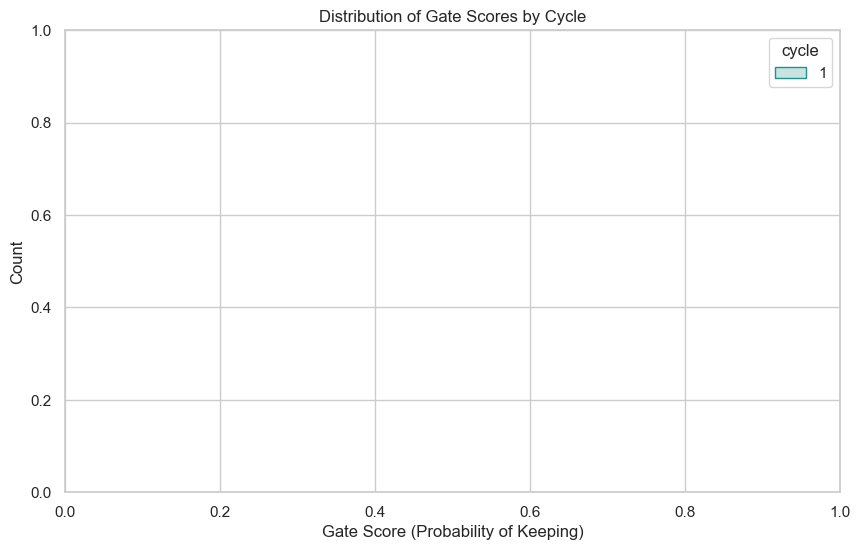

In [5]:
if not df.empty:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x='gate_score', hue='cycle', element="step", bins=20, palette="viridis")
    plt.title("Distribution of Gate Scores by Cycle")
    plt.xlabel("Gate Score (Probability of Keeping)")
    plt.ylabel("Count")
    plt.show()

## 2. Similarity vs. Gate Score
Does the filter just learn to mimic the similarity score? 
- If points lie on the diagonal, the filter is redundant (Gate ≈ Similarity).
- If points are scattered, the filter is learning a distinct signal (e.g., rejecting high-similarity but irrelevant memories).

In [ ]:
if not df.empty:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='similarity_score', y='gate_score', hue='cycle', palette="viridis", alpha=0.6)
    plt.title("Similarity Score vs. Gate Score")
    plt.xlabel("Retrieval Similarity Score")
    plt.ylabel("Filter Gate Score")
    plt.plot([0, 1], [0, 1], 'r--', label="Identity (Redundant)")
    plt.legend()
    plt.show()

## 3. Qualitative Analysis
Let's look at specific examples where the filter made a strong decision.
- **Kept (High Score)**: What does the agent think is useful?
- **Discarded (Low Score)**: What does the agent think is noise?

In [ ]:
def print_example(row):
    print("="*80)
    print(f"Cycle: {row['cycle']} | Gate Score: {row['gate_score']:.4f} | Action: {'KEEP' if row['gate_action'] else 'DISCARD'}")
    print(f"Similarity: {row['similarity_score']:.4f}")
    print("-"*80)
    print(f"GOAL: {row['goal_text']}")
    print("-"*80)
    print(f"OBSERVATION (Snippet): {row['observation_text'][:200]}...")
    print("-"*80)
    print(f"MEMORY CONTENT:\n{row['memory_content']}")
    print("="*80 + "\n")

if not df.empty:
    print("### EXAMPLES OF HIGH CONFIDENCE 'KEEP' ###")
    high_conf_keep = df[df['gate_score'] > 0.8].sample(min(3, len(df[df['gate_score'] > 0.8])))
    for _, row in high_conf_keep.iterrows():
        print_example(row)

    print("\n### EXAMPLES OF HIGH CONFIDENCE 'DISCARD' ###")
    high_conf_discard = df[df['gate_score'] < 0.2].sample(min(3, len(df[df['gate_score'] < 0.2])))
    for _, row in high_conf_discard.iterrows():
        print_example(row)

## 4. Success Rate Correlation
Do episodes with higher average gate scores tend to succeed more?

ValueError: List of boxplot statistics and `positions` values must have same the length

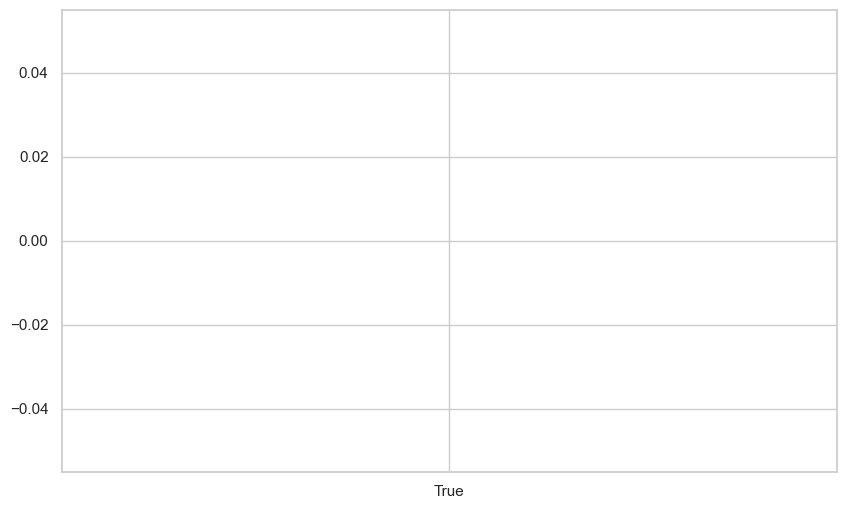

In [6]:
if not df.empty:
    # Group by episode
    episode_stats = df.groupby('episode_id').agg({
        'gate_score': 'mean',
        'success': 'first',
        'final_reward': 'first',
        'cycle': 'first'
    }).reset_index()

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=episode_stats, x='success', y='gate_score')
    plt.title("Average Gate Score vs. Episode Success")
    plt.xlabel("Success")
    plt.ylabel("Average Gate Score in Episode")
    plt.show()